In [51]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, RANSACRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import HuberRegressor

In [52]:
df = pd.read_csv('Limpieza/data/INFORMACIÓN_TRIMESTRAL_DE_ACCESOS_FIJOS_A_INTERNET_POR_PROVEEDOR,_DEPARTAMENTO,_MUNICIPIO,_SEGMENTO,_TECNOLOGIA,_Y_VELOCIDAD_DE_CONEXIÓN_COMPLETO.csv')

In [53]:
df.columns

Index(['AÑO', 'TRIMESTRE', 'PROVEEDOR', 'CÓDIGO DANE', 'DEPARTAMENTO',
       'CÓDIGO DANE.1', 'MUNICIPIO', 'SEGMENTO', 'TECNOLOGÍA',
       'VELOCIDAD BAJADA', 'VELOCIDAD SUBIDA', 'No. ACCESOS FIJOS A INTERNET'],
      dtype='object')

In [54]:
municipios_unicos = df['MUNICIPIO'].unique()

In [55]:
municipios_unicos

array(['CALI', 'AMALFI', 'BARBOSA', ..., 'PANA PANA', 'PAPUNAHUA',
       'MIRITI - PARANÁ'], dtype=object)

In [56]:
numero_municipios = df['MUNICIPIO'].value_counts()

In [57]:
# Contar valores únicos en la columna MUNICIPIO
n_municipios = df['MUNICIPIO'].nunique()

In [58]:
n_municipios

1036

In [59]:
# 1. Crear nueva columna TRIMESTRE
df['TRIMESTRE'] = ((df['AÑO'] - 2021) * 4 + df['TRIMESTRE'])

In [60]:
# 2. Concatenar DEPARTAMENTO y MUNICIPIO con un punto
df['UBICACION'] = df['DEPARTAMENTO'] + '.' + df['MUNICIPIO']

In [61]:
# 3. Seleccionar solo las columnas que necesitamos
df_final = df[[
    'TRIMESTRE',
    'UBICACION',
    'VELOCIDAD BAJADA',
    'VELOCIDAD SUBIDA',
    'No. ACCESOS FIJOS A INTERNET',
    'TECNOLOGÍA'
]].copy()

In [62]:
# Para verificar el resultado
print("Muestra de valores únicos en TRIMESTRE:")
print(df['TRIMESTRE'].unique())

Muestra de valores únicos en TRIMESTRE:
[ 3  4  5  6  7  8  9 10 11 12 13]


In [63]:
print("\nPrimeras filas del dataset transformado:")
print(df_final.head())


Primeras filas del dataset transformado:
   TRIMESTRE             UBICACION  VELOCIDAD BAJADA  VELOCIDAD SUBIDA  \
0          3  VALLE DEL CAUCA.CALI               3.0               1.5   
1          3  VALLE DEL CAUCA.CALI               2.0               1.0   
2          3  VALLE DEL CAUCA.CALI               4.0               2.0   
3          3      ANTIOQUIA.AMALFI              20.0               5.0   
4          3      ANTIOQUIA.AMALFI              30.0               5.0   

   No. ACCESOS FIJOS A INTERNET                TECNOLOGÍA  
0                             3  FIBER TO THE HOME (FTTH)  
1                            12  FIBER TO THE HOME (FTTH)  
2                             7  FIBER TO THE HOME (FTTH)  
3                             1  FIBER TO THE HOME (FTTH)  
4                             1  FIBER TO THE HOME (FTTH)  


In [64]:
# Exportar a CSV
#df_final.to_csv('dataset_prediccion.csv', index=False)

In [65]:
# Obtener lista de ubicaciones únicas
ubicaciones = df_final['UBICACION'].unique()

In [66]:
# Para cada ubicación, crear y guardar su subdataset
for ubicacion in ubicaciones:
    # Filtrar el dataframe para esta ubicación
    df_ubicacion = df_final[df_final['UBICACION'] == ubicacion]

    # Seleccionar solo las columnas necesarias
    df_ubicacion = df_ubicacion[[
        'TRIMESTRE',
        'VELOCIDAD BAJADA',
        'VELOCIDAD SUBIDA',
        'No. ACCESOS FIJOS A INTERNET',
        'TECNOLOGÍA'
    ]]

    # Crear nombre de archivo (reemplazando caracteres problemáticos)
    nombre_archivo = ubicacion.replace('/', '_').replace('\\', '_')
    ruta_archivo = f'Limpieza/data/subdatasets-ubicacion/{nombre_archivo}.csv'

    # Guardar el archivo
    df_ubicacion.to_csv(ruta_archivo, index=False)

print(f"Se han creado {len(ubicaciones)} archivos en Limpieza/data/subdatasets-ubicacion/")

Se han creado 1121 archivos en Limpieza/data/subdatasets-ubicacion/


In [67]:
# Leer un dataset específico de la carpeta de subdatasets
nombre_municipio = 'ANTIOQUIA.AMALFI'  # Ejemplo, cámbialo por el que quieras ver
ruta_archivo = f'Limpieza/data/subdatasets-ubicacion/{nombre_municipio}.csv'
df_municipio = pd.read_csv(ruta_archivo)


FIBER TO THE HOME (FTTH):
Tendencia de velocidad: 4.30 Mbps/trimestre (R² = 0.66)
Velocidad promedio: 33.80 ± 78.12 Mbps
Accesos promedio: 20.06 ± 50.59

SATELITAL:
Tendencia de velocidad: -0.31 Mbps/trimestre (R² = 0.21)
Velocidad promedio: 20.80 ± 14.50 Mbps
Accesos promedio: 19.15 ± 29.18

XDSL:
Tendencia de velocidad: 0.01 Mbps/trimestre (R² = 0.10)
Velocidad promedio: 4.90 ± 3.62 Mbps
Accesos promedio: 15.70 ± 21.01

OTRAS TECNOLOGÍAS FIJAS:
Tendencia de velocidad: 0.00 Mbps/trimestre (R² = 1.00)
Velocidad promedio: 0.56 ± 0.62 Mbps
Accesos promedio: 1.00 ± 0.00

OTRAS TECNOLOGÍAS INALÁMBRICAS:
Tendencia de velocidad: 0.19 Mbps/trimestre (R² = 0.43)
Velocidad promedio: 3.27 ± 2.88 Mbps
Accesos promedio: 1.21 ± 0.68

OTRAS TECNOLOGÍAS DE FIBRA (ANTES FTTX):
Tendencia de velocidad: 934.34 Mbps/trimestre (R² = 0.85)
Velocidad promedio: 3226.61 ± 33.76 Mbps
Accesos promedio: 3.49 ± 2.18

FIBER TO THE BUILDING O FIBER TO THE BASEMENT (FTTB):
Tendencia de velocidad: 0.00 Mbps/trimestre

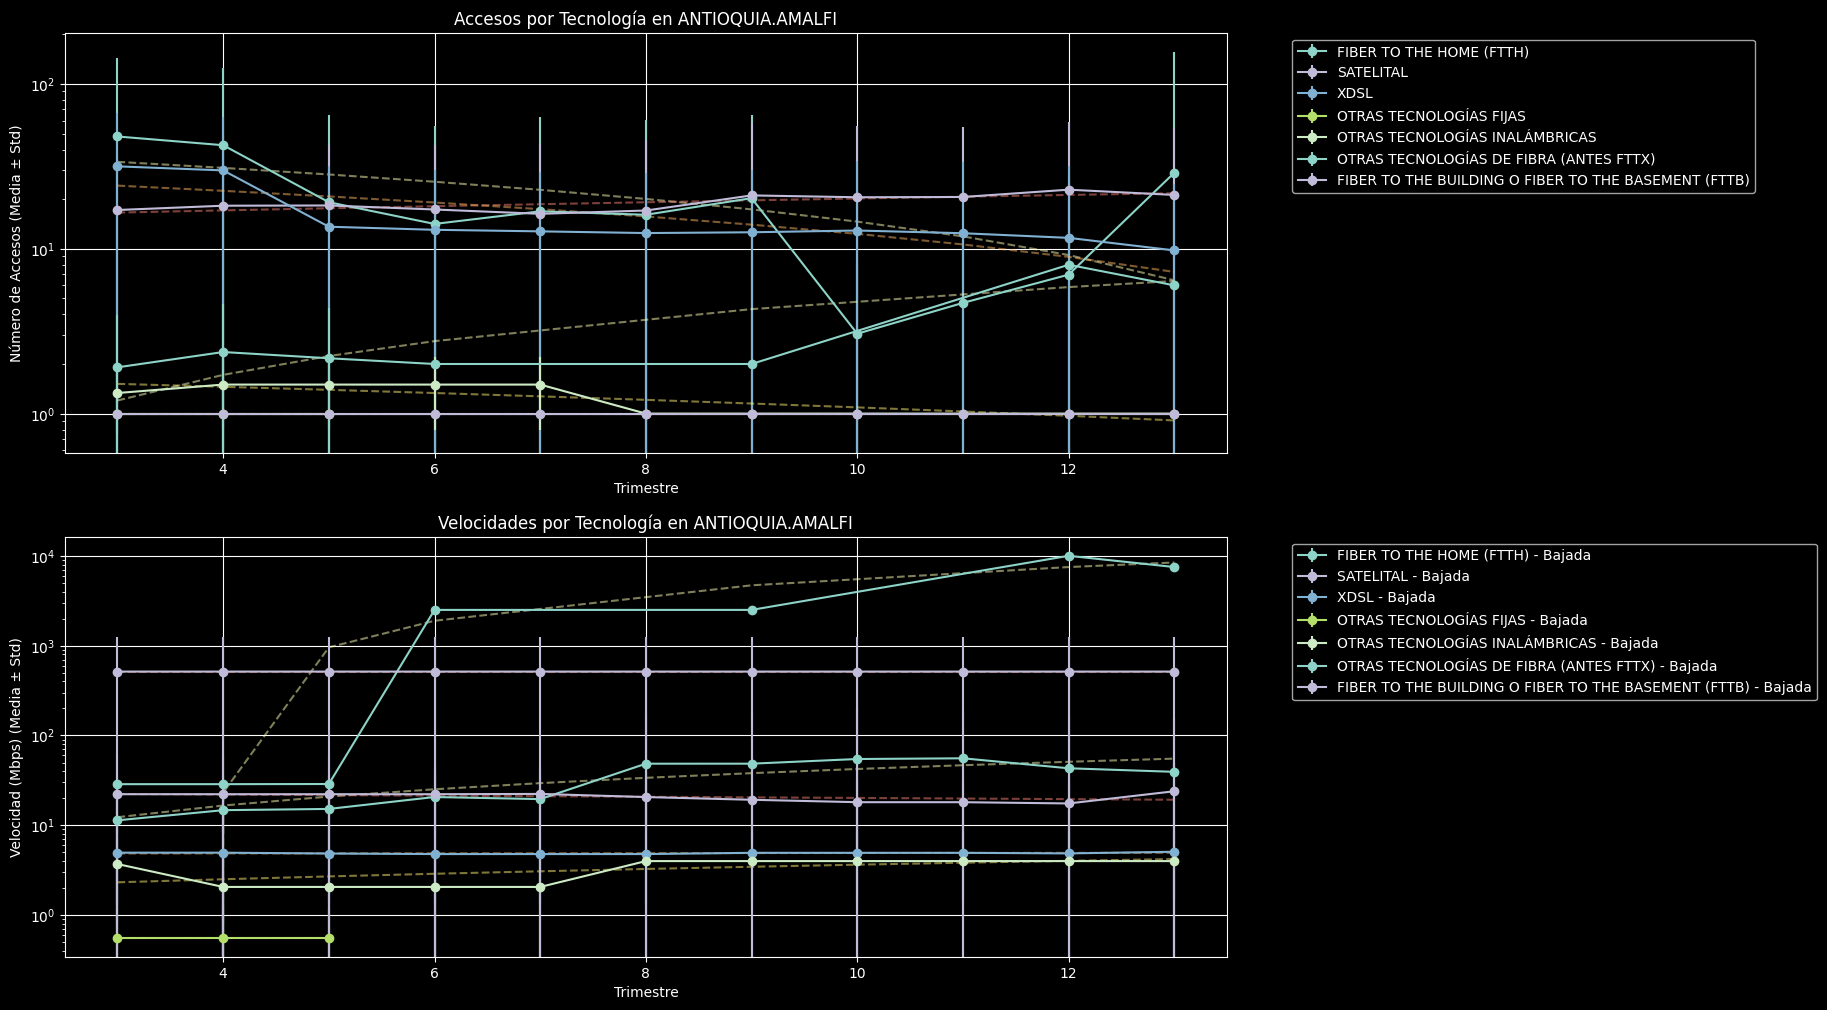

In [103]:
def analizar_tecnologias(df):
    # Calcular estadísticas por trimestre y tecnología
    stats_por_trimestre = df.groupby(['TRIMESTRE', 'TECNOLOGÍA']).agg({
        'VELOCIDAD BAJADA': ['mean', 'std'],
        'VELOCIDAD SUBIDA': ['mean', 'std'],
        'No. ACCESOS FIJOS A INTERNET': ['mean', 'std']
    }).reset_index()

    # Renombrar columnas para claridad
    stats_por_trimestre.columns = [
        'TRIMESTRE', 'TECNOLOGÍA',
        'VELOCIDAD_BAJADA_MEAN', 'VELOCIDAD_BAJADA_STD',
        'VELOCIDAD_SUBIDA_MEAN', 'VELOCIDAD_SUBIDA_STD',
        'ACCESOS_MEAN', 'ACCESOS_STD'
    ]

    # Crear figura
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

    # Graficar accesos por tecnología
    for tecnologia in df['TECNOLOGÍA'].unique():
        datos_tech = stats_por_trimestre[stats_por_trimestre['TECNOLOGÍA'] == tecnologia]

        # Regresión lineal para accesos
        modelo = LinearRegression()
        X = datos_tech['TRIMESTRE'].values.reshape(-1, 1)
        y = datos_tech['ACCESOS_MEAN'].values
        modelo.fit(X, y)
        y_pred = modelo.predict(X)

        # Graficar datos y regresión
        ax1.errorbar(datos_tech['TRIMESTRE'], datos_tech['ACCESOS_MEAN'],
                     yerr=datos_tech['ACCESOS_STD'], fmt='o-', label=f'{tecnologia}')
        ax1.plot(X, y_pred, '--', alpha=0.5)

    ax1.set_title(f'Accesos por Tecnología en {nombre_municipio}')
    ax1.set_xlabel('Trimestre')
    ax1.set_ylabel('Número de Accesos (Media ± Std)')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True)
    ax1.set_yscale('log')  # Aplicar escala logarítmica al primer subplot

    # Graficar velocidades por tecnología
    for tecnologia in df['TECNOLOGÍA'].unique():
        datos_tech = stats_por_trimestre[stats_por_trimestre['TECNOLOGÍA'] == tecnologia]

        # Regresión lineal para velocidades
        modelo = LinearRegression()
        X = datos_tech['TRIMESTRE'].values.reshape(-1, 1)
        y = datos_tech['VELOCIDAD_BAJADA_MEAN'].values
        modelo.fit(X, y)
        y_pred = modelo.predict(X)

        # Graficar datos y regresión
        ax2.errorbar(datos_tech['TRIMESTRE'], datos_tech['VELOCIDAD_BAJADA_MEAN'],
                     yerr=datos_tech['VELOCIDAD_BAJADA_STD'], fmt='o-',
                     label=f'{tecnologia} - Bajada')
        ax2.plot(X, y_pred, '--', alpha=0.5)

    ax2.set_title(f'Velocidades por Tecnología en {nombre_municipio}')
    ax2.set_xlabel('Trimestre')
    ax2.set_ylabel('Velocidad (Mbps) (Media ± Std)')
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True)
    ax2.set_yscale('log')  # Aplicar escala logarítmica al segundo subplot

    return stats_por_trimestre

# Ejecutar el análisis
stats_tecnologia = analizar_tecnologias(df_municipio)

# Imprimir estadísticas y tendencias
for tecnologia in df_municipio['TECNOLOGÍA'].unique():
    datos_tech = stats_tecnologia[stats_tecnologia['TECNOLOGÍA'] == tecnologia]

    # Calcular tendencias
    if len(datos_tech) > 1:
        modelo_velocidad = LinearRegression()
        X = datos_tech['TRIMESTRE'].values.reshape(-1, 1)
        y = datos_tech['VELOCIDAD_BAJADA_MEAN'].values
        modelo_velocidad.fit(X, y)

        pendiente_velocidad = modelo_velocidad.coef_[0]
        r2_velocidad = r2_score(y, modelo_velocidad.predict(X))

        print(f"\n{tecnologia}:")
        print(f"Tendencia de velocidad: {pendiente_velocidad:.2f} Mbps/trimestre (R² = {r2_velocidad:.2f})")
        print(f"Velocidad promedio: {datos_tech['VELOCIDAD_BAJADA_MEAN'].mean():.2f} ± {datos_tech['VELOCIDAD_BAJADA_STD'].mean():.2f} Mbps")
        print(f"Accesos promedio: {datos_tech['ACCESOS_MEAN'].mean():.2f} ± {datos_tech['ACCESOS_STD'].mean():.2f}")

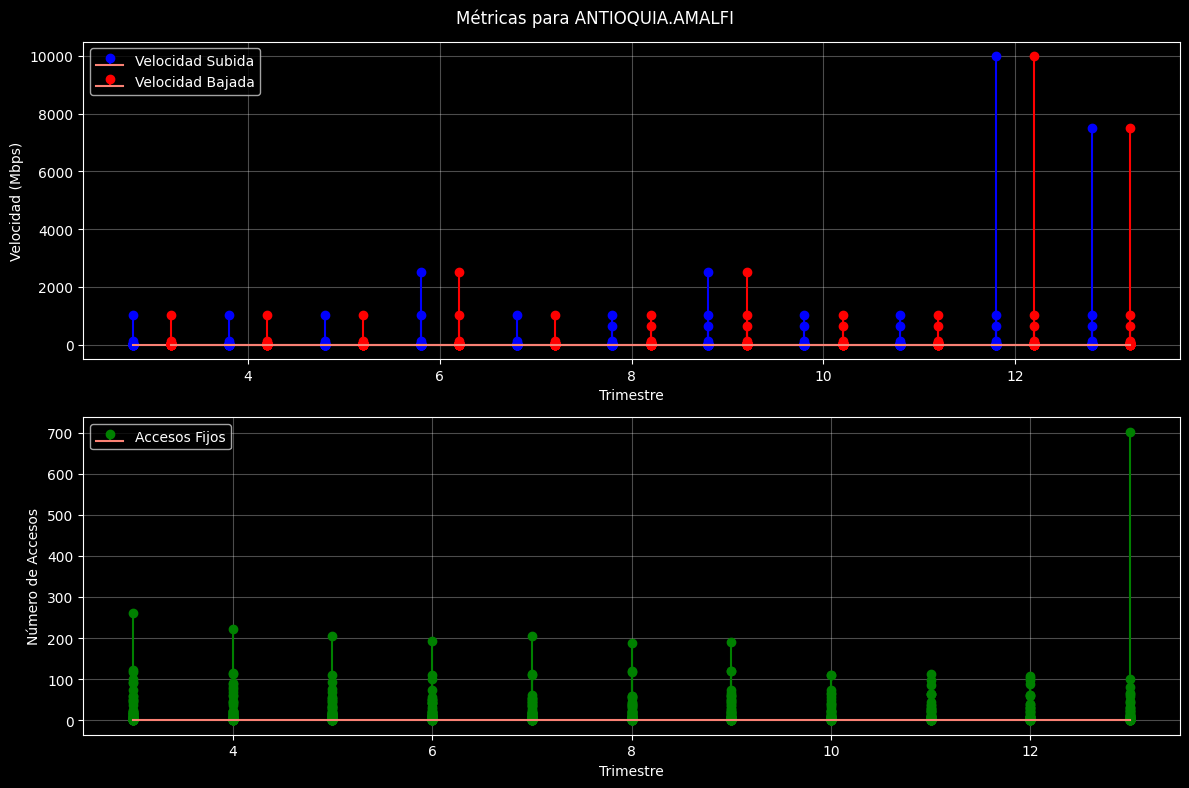

In [69]:

# Crear figura y ejes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Agregar un pequeño offset para separar las velocidades
offset = 0.2

# Graficar velocidades en el primer eje
markerline1, stemlines1, baseline1 = ax1.stem(df_municipio['TRIMESTRE'] - offset,
                                              df_municipio['VELOCIDAD SUBIDA'],
                                              label='Velocidad Subida',
                                              linefmt='b-',
                                              markerfmt='bo')
markerline2, stemlines2, baseline2 = ax1.stem(df_municipio['TRIMESTRE'] + offset,
                                              df_municipio['VELOCIDAD BAJADA'],
                                              label='Velocidad Bajada',
                                              linefmt='r-',
                                              markerfmt='ro')

# Graficar accesos en el segundo eje
markerline3, stemlines3, baseline3 = ax2.stem(df_municipio['TRIMESTRE'],
                                              df_municipio['No. ACCESOS FIJOS A INTERNET'],
                                              label='Accesos Fijos',
                                              linefmt='g-',
                                              markerfmt='go')

# Configurar etiquetas y título
ax1.set_xlabel('Trimestre')
ax1.set_ylabel('Velocidad (Mbps)')
ax2.set_xlabel('Trimestre')
ax2.set_ylabel('Número de Accesos')
fig.suptitle(f'Métricas para {nombre_municipio}')

# Agregar leyendas
ax1.legend(loc='upper left')
ax2.legend(loc='upper left')

# Ajustar diseño y estilo
plt.style.use('dark_background')
ax1.grid(True, alpha=0.3)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [70]:
# Preparar datos para la regresión
X = df_municipio[['TRIMESTRE']].values
y = df_municipio['VELOCIDAD BAJADA'].values

In [71]:
# Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [72]:
# Crear y entrenar el modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

LinearRegression()

In [73]:
# Hacer predicciones
y_pred = modelo.predict(X)

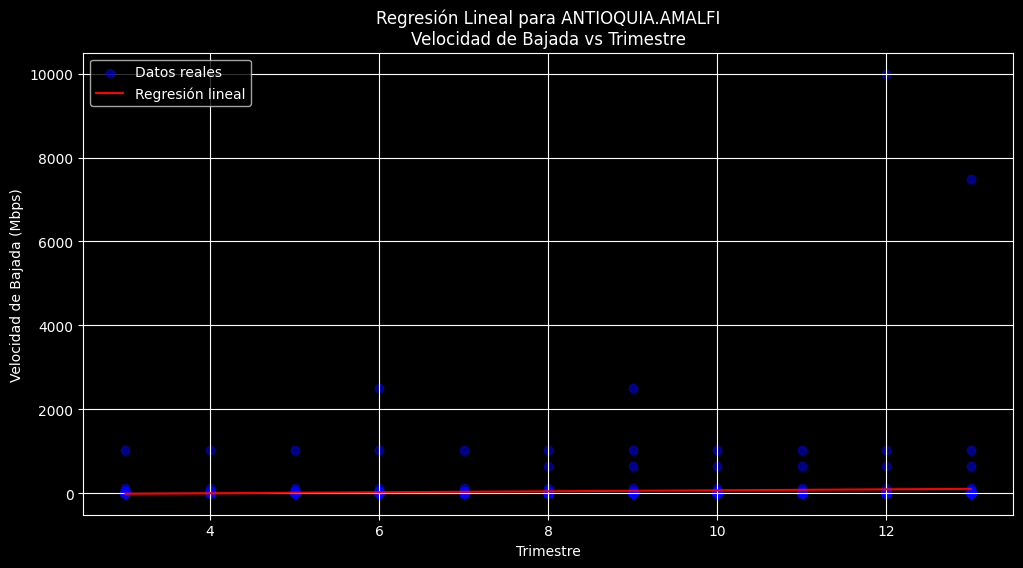

In [74]:
# Visualizar resultados
plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='blue', alpha=0.5, label='Datos reales')
plt.plot(X, y_pred, color='red', label='Regresión lineal')
plt.xlabel('Trimestre')
plt.ylabel('Velocidad de Bajada (Mbps)')
plt.title(f'Regresión Lineal para {nombre_municipio}\nVelocidad de Bajada vs Trimestre')
plt.legend()
plt.grid(True)
plt.show()

In [75]:
# Mostrar métricas
print("\nMétricas del modelo:")
print(f"Coeficiente (pendiente): {modelo.coef_[0]:.2f}")
print(f"Intercepto: {modelo.intercept_:.2f}")
print(f"R² Score: {r2_score(y, y_pred):.4f}")
print(f"Error cuadrático medio: {mean_squared_error(y, y_pred):.2f}")
print(f"Raíz del error cuadrático medio: {np.sqrt(mean_squared_error(y, y_pred)):.2f}")


Métricas del modelo:
Coeficiente (pendiente): 11.67
Intercepto: -48.33
R² Score: 0.0027
Error cuadrático medio: 174764.14
Raíz del error cuadrático medio: 418.05


In [76]:
# Crear y entrenar el modelo RANSAC
ransac = RANSACRegressor(random_state=42)
ransac.fit(X, y)

RANSACRegressor(random_state=42)

In [77]:
# Predicciones
y_pred = ransac.predict(X)

In [78]:
# Obtener la máscara de inliers/outliers
inlier_mask = ransac.inlier_mask_
outlier_mask = np.logical_not(inlier_mask)

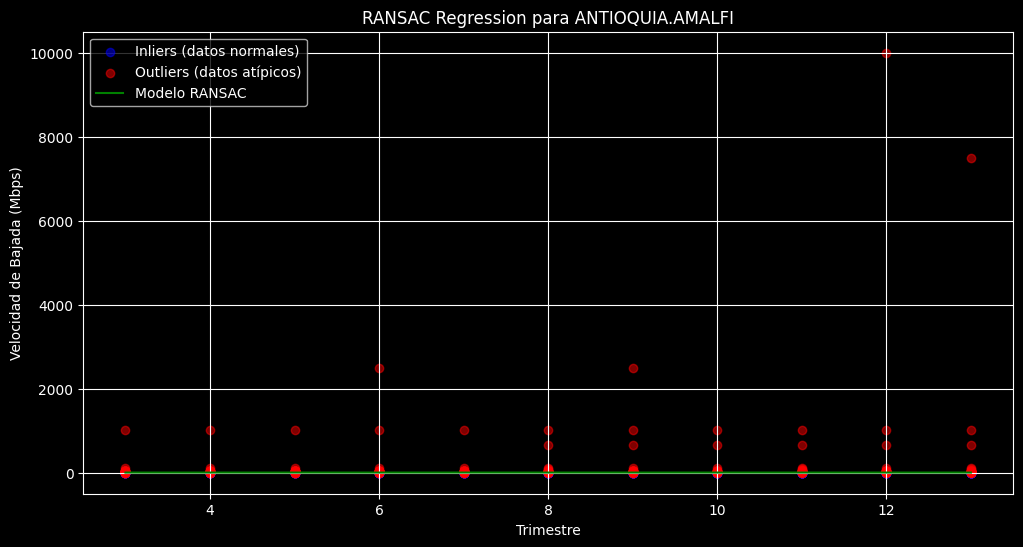

In [79]:
# Visualización
plt.figure(figsize=(12, 6))
plt.scatter(X[inlier_mask], y[inlier_mask], color='blue', alpha=0.5,
            label='Inliers (datos normales)')
plt.scatter(X[outlier_mask], y[outlier_mask], color='red', alpha=0.5,
            label='Outliers (datos atípicos)')
plt.plot(X, y_pred, color='green', label='Modelo RANSAC')
plt.xlabel('Trimestre')
plt.ylabel('Velocidad de Bajada (Mbps)')
plt.title(f'RANSAC Regression para {nombre_municipio}')
plt.legend()
plt.grid(True)
plt.show()

In [80]:
# Métricas
print("\nMétricas del modelo RANSAC:")
print(f"R² Score: {r2_score(y, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y, y_pred)):.2f}")
print(f"Número de inliers: {np.sum(inlier_mask)}")
print(f"Número de outliers: {np.sum(outlier_mask)}")


Métricas del modelo RANSAC:
R² Score: -0.0112
RMSE: 420.95
Número de inliers: 557
Número de outliers: 475


In [81]:
# Definir parámetros a probar con los nombres correctos
param_grid = {
    'min_samples': [10, 50, 100],
    'residual_threshold': [50, 100, 200],
    'max_trials': [50, 100, 200],
    'loss': ['absolute_error', 'squared_error']  # Nombres corregidos
}

In [82]:
# Crear modelo base
ransac = RANSACRegressor(random_state=42)

In [83]:
# Búsqueda de mejores parámetros
grid_search = GridSearchCV(ransac, param_grid, cv=5, scoring='r2')
grid_search.fit(X, y)

GridSearchCV(cv=5, estimator=RANSACRegressor(random_state=42),
             param_grid={'loss': ['absolute_error', 'squared_error'],
                         'max_trials': [50, 100, 200],
                         'min_samples': [10, 50, 100],
                         'residual_threshold': [50, 100, 200]},
             scoring='r2')

In [84]:
# Crear modelo base
ransac = RANSACRegressor(random_state=42)

In [85]:
# Búsqueda de mejores parámetros
grid_search = GridSearchCV(ransac, param_grid, cv=5, scoring='r2')
grid_search.fit(X, y)

GridSearchCV(cv=5, estimator=RANSACRegressor(random_state=42),
             param_grid={'loss': ['absolute_error', 'squared_error'],
                         'max_trials': [50, 100, 200],
                         'min_samples': [10, 50, 100],
                         'residual_threshold': [50, 100, 200]},
             scoring='r2')

In [86]:
print("\nMejores parámetros encontrados:")
print(grid_search.best_params_)
print(f"Mejor score: {grid_search.best_score_:.4f}")


Mejores parámetros encontrados:
{'loss': 'absolute_error', 'max_trials': 50, 'min_samples': 10, 'residual_threshold': 200}
Mejor score: -0.0139


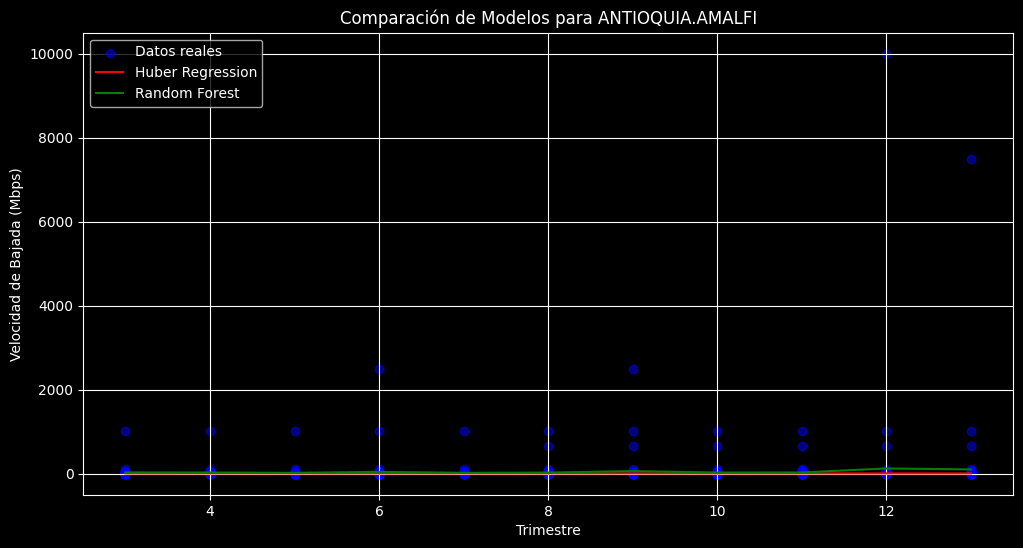


Métricas de los modelos:

Huber Regression:
R² Score: -0.0095
RMSE: 420.59

Random Forest:
R² Score: 0.0071
RMSE: 417.13


In [87]:
# Entrenar modelos
huber = HuberRegressor()
rf = RandomForestRegressor(n_estimators=100, random_state=42)

huber.fit(X, y)
rf.fit(X, y)

# Predicciones
y_pred_huber = huber.predict(X)
y_pred_rf = rf.predict(X)

# Visualización
plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='blue', alpha=0.5, label='Datos reales')
plt.plot(X, y_pred_huber, color='red', label='Huber Regression')
plt.plot(X, y_pred_rf, color='green', label='Random Forest')
plt.xlabel('Trimestre')
plt.ylabel('Velocidad de Bajada (Mbps)')
plt.title(f'Comparación de Modelos para {nombre_municipio}')
plt.legend()
plt.grid(True)
plt.show()

# Métricas
print("\nMétricas de los modelos:")
print("\nHuber Regression:")
print(f"R² Score: {r2_score(y, y_pred_huber):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y, y_pred_huber)):.2f}")

print("\nRandom Forest:")
print(f"R² Score: {r2_score(y, y_pred_rf):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y, y_pred_rf)):.2f}")

In [88]:
# Calcular promedio y desviación estándar por trimestre
df_stats = df_final.groupby('TRIMESTRE').agg({
    'VELOCIDAD BAJADA': ['mean', 'std'],
    'VELOCIDAD SUBIDA': ['mean', 'std'],
    'No. ACCESOS FIJOS A INTERNET': ['mean', 'std']
}).reset_index()

In [89]:
# Renombrar columnas para claridad
df_stats.columns = [
    'TRIMESTRE',
    'BAJADA_MEDIA', 'BAJADA_STD',
    'SUBIDA_MEDIA', 'SUBIDA_STD',
    'ACCESOS_MEDIA', 'ACCESOS_STD'
]

In [90]:
df_stats.columns

Index(['TRIMESTRE', 'BAJADA_MEDIA', 'BAJADA_STD', 'SUBIDA_MEDIA', 'SUBIDA_STD',
       'ACCESOS_MEDIA', 'ACCESOS_STD'],
      dtype='object')

In [91]:
# Aplicar regresión lineal al dataset promediado
X = df_stats[['TRIMESTRE']].values
y = df_stats['BAJADA_MEDIA'].values

In [92]:
# Crear y entrenar el modelo
modelo = LinearRegression()
modelo.fit(X, y)
y_pred = modelo.predict(X)

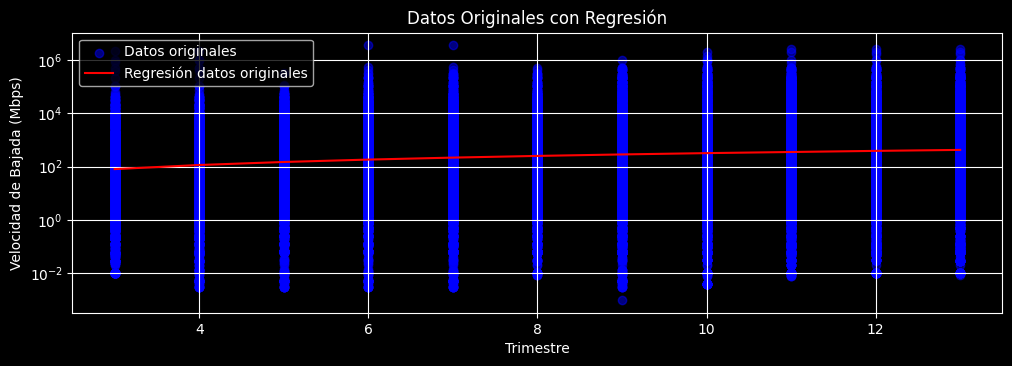

In [93]:
# Visualización
plt.figure(figsize=(12, 8))

# Subplot 1: Datos originales
plt.subplot(2, 1, 1)
plt.scatter(df['TRIMESTRE'], df['VELOCIDAD BAJADA'], color='blue', alpha=0.5, label='Datos originales')
plt.plot(df['TRIMESTRE'], modelo.predict(df[['TRIMESTRE']]), color='red', label='Regresión datos originales')
plt.xlabel('Trimestre')
plt.ylabel('Velocidad de Bajada (Mbps)')
plt.title('Datos Originales con Regresión')
plt.yscale('log')
plt.legend()
plt.grid(True)

* Muestra todos los datos crudos (puntos azules) de velocidad de bajada
* La escala es logarítmica (note los valores 10^-2 hasta 10^6)
* Los puntos verticales azules representan todos los valores registrados en cada trimestre
* La línea roja es la regresión lineal sobre estos datos originales
* Se puede ver mucha dispersión en los datos (valores muy altos y muy bajos)

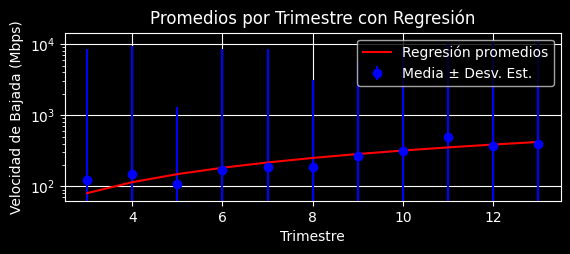

In [94]:
# Subplot 2: Datos promediados
plt.subplot(2, 1, 2)
plt.errorbar(df_stats['TRIMESTRE'], df_stats['BAJADA_MEDIA'],
             yerr=df_stats['BAJADA_STD'], fmt='o', color='blue',
             label='Media ± Desv. Est.')
plt.plot(X, y_pred, color='red', label='Regresión promedios')
plt.xlabel('Trimestre')
plt.ylabel('Velocidad de Bajada (Mbps)')
plt.title('Promedios por Trimestre con Regresión')
plt.yscale('log')
plt.legend()
plt.grid(True)

* Muestra el promedio de los datos por trimestre (puntos azules)
* Las barras verticales azules representan la desviación estándar (variabilidad de los datos)
* La línea roja es la regresión lineal sobre estos promedios
* También usa escala logarítmica pero con menos rango (10^2 hasta 10^4)
* Se ve una tendencia más clara al trabajar con promedios
* Las barras de error (líneas verticales) muestran qué tan dispersos están los datos alrededor de la media

In [95]:
# Métricas para ambos modelos
print("\nMétricas del modelo con datos originales:")
y_pred_orig = modelo.predict(df[['TRIMESTRE']])
print(f"R² Score: {r2_score(df['VELOCIDAD BAJADA'], y_pred_orig):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(df['VELOCIDAD BAJADA'], y_pred_orig)):.2f}")

print("\nMétricas del modelo con promedios:")
print(f"R² Score: {r2_score(y, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y, y_pred)):.2f}")

# Mostrar los datos procesados
print("\nDatos procesados por trimestre:")
print(df_stats)


Métricas del modelo con datos originales:
R² Score: 0.0002
RMSE: 8175.15

Métricas del modelo con promedios:
R² Score: 0.8123
RMSE: 51.74

Datos procesados por trimestre:
    TRIMESTRE  BAJADA_MEDIA    BAJADA_STD  SUBIDA_MEDIA    SUBIDA_STD  \
0           3    123.448839   8328.989856     96.346192   8245.317315   
1           4    147.568014   9187.979004    118.974076   9113.936015   
2           5    109.165345   1199.295442     69.085370   1152.406413   
3           6    171.776605   8412.001892    121.748812   8309.975153   
4           7    186.845392   8477.490846    134.819716   8376.188538   
5           8    185.768141   2936.640817    130.111305   2869.438952   
6           9    268.195256   5259.312389    209.559490   5153.620118   
7          10    309.584481   8812.002036    217.956495   7601.690532   
8          11    488.597723  10048.601998    408.003013   9991.360058   
9          12    366.011163  10516.826568    301.823625  10417.586729   
10         13    398.4297

In [96]:
def analizar_municipio(ruta_archivo):
    # Leer dataset
    df = pd.read_csv(ruta_archivo)
    nombre_municipio = ruta_archivo.split('/')[-1].replace('.csv', '')

    # Asegurarnos que TRIMESTRE sea entero
    df['TRIMESTRE'] = df['TRIMESTRE'].astype(int)

    # Calcular estadísticas por trimestre
    df_stats = df.groupby('TRIMESTRE').agg({
        'VELOCIDAD BAJADA': ['mean', 'std'],
        'VELOCIDAD SUBIDA': ['mean', 'std'],
        'No. ACCESOS FIJOS A INTERNET': ['mean', 'std']
    }).reset_index()

    # Añadir análisis por tecnología
    stats_tecnologia = df.groupby(['TECNOLOGÍA']).agg({
        'VELOCIDAD BAJADA': ['mean', 'max'],
        'VELOCIDAD SUBIDA': ['mean', 'max'],
        'No. ACCESOS FIJOS A INTERNET': ['sum', 'mean']
    }).reset_index()


    # Renombrar columnas
    df_stats.columns = [
        'TRIMESTRE',
        'BAJADA_MEDIA', 'BAJADA_STD',
        'SUBIDA_MEDIA', 'SUBIDA_STD',
        'ACCESOS_MEDIA', 'ACCESOS_STD'
    ]

    # Crear modelos de regresión para cada variable
    X = df_stats[['TRIMESTRE']].values

    # Modelo para velocidad de bajada
    modelo_bajada = LinearRegression()
    modelo_bajada.fit(X, df_stats['BAJADA_MEDIA'])

    # Modelo para velocidad de subida
    modelo_subida = LinearRegression()
    modelo_subida.fit(X, df_stats['SUBIDA_MEDIA'])

    # Modelo para accesos
    modelo_accesos = LinearRegression()
    modelo_accesos.fit(X, df_stats['ACCESOS_MEDIA'])

    # Generar proyecciones para 3 años (12 trimestres)
    ultimo_trimestre = int(df_stats['TRIMESTRE'].max())
    trimestres_futuros = np.arange(ultimo_trimestre + 1, ultimo_trimestre + 13).reshape(-1, 1)

    proyecciones_bajada = modelo_bajada.predict(trimestres_futuros)
    proyecciones_subida = modelo_subida.predict(trimestres_futuros)
    proyecciones_accesos = modelo_accesos.predict(trimestres_futuros)

    # Calcular métricas para cada modelo
    metricas = {
        'bajada': {
            'R2': r2_score(df_stats['BAJADA_MEDIA'], modelo_bajada.predict(X)),
            'RMSE': np.sqrt(mean_squared_error(df_stats['BAJADA_MEDIA'], modelo_bajada.predict(X))),
            'pendiente': modelo_bajada.coef_[0],
            'intercepto': modelo_bajada.intercept_
        },
        'subida': {
            'R2': r2_score(df_stats['SUBIDA_MEDIA'], modelo_subida.predict(X)),
            'RMSE': np.sqrt(mean_squared_error(df_stats['SUBIDA_MEDIA'], modelo_subida.predict(X))),
            'pendiente': modelo_subida.coef_[0],
            'intercepto': modelo_subida.intercept_
        },
        'accesos': {
            'R2': r2_score(df_stats['ACCESOS_MEDIA'], modelo_accesos.predict(X)),
            'RMSE': np.sqrt(mean_squared_error(df_stats['ACCESOS_MEDIA'], modelo_accesos.predict(X))),
            'pendiente': modelo_accesos.coef_[0],
            'intercepto': modelo_accesos.intercept_
        }
    }

    return {
        'municipio': nombre_municipio,
        'metricas': metricas,
        'estadisticas': df_stats.to_dict('records'),
        'proyecciones': list(zip(
            trimestres_futuros.flatten(),
            proyecciones_bajada,
            proyecciones_subida,
            proyecciones_accesos
        )),
        'tecnologias': stats_tecnologia.to_dict('records')  # Nueva sección
    }

In [97]:
import warnings
warnings.filterwarnings('ignore')

In [98]:
# Procesar todos los archivos
resultados = []
directorio = 'Limpieza/data/subdatasets-ubicacion/'

for archivo in os.listdir(directorio):
    if archivo.endswith('.csv'):
        try:
            resultado = analizar_municipio(os.path.join(directorio, archivo))
            resultados.append(resultado)
            print(f"Procesado exitosamente: {archivo}")
        except Exception as e:
            print(f"Error procesando {archivo}: {str(e)}")

print(f"\nTotal de archivos procesados: {len(resultados)}")

Procesado exitosamente: SANTANDER.TONA.csv
Procesado exitosamente: CUNDINAMARCA.SAN CAYETANO.csv
Procesado exitosamente: SANTANDER.VETAS.csv
Procesado exitosamente: AMAZONAS.LETICIA.csv
Procesado exitosamente: ATLÁNTICO.SANTA LUCÍA.csv
Procesado exitosamente: SANTANDER.GUACA.csv
Procesado exitosamente: NORTE DE SANTANDER.PAMPLONITA.csv
Procesado exitosamente: CASANARE.YOPAL.csv
Procesado exitosamente: CAUCA.CORINTO.csv
Procesado exitosamente: BOYACÁ.MOTAVITA.csv
Procesado exitosamente: SANTANDER.ALBANIA.csv
Procesado exitosamente: CALDAS.SAN JOSÉ.csv
Procesado exitosamente: CUNDINAMARCA.PULÍ.csv
Procesado exitosamente: SANTANDER.ARATOCA.csv
Procesado exitosamente: ANTIOQUIA.ANGELÓPOLIS.csv
Procesado exitosamente: ANTIOQUIA.CARAMANTA.csv
Procesado exitosamente: ANTIOQUIA.ABRIAQUÍ.csv
Procesado exitosamente: GUAINÍA.INÍRIDA.csv
Procesado exitosamente: CUNDINAMARCA.VENECIA.csv
Procesado exitosamente: TOLIMA.MURILLO.csv
Procesado exitosamente: BOLÍVAR.MAHATES.csv
Procesado exitosamente: AR

In [99]:
# Crear archivo Markdown con resultados
with open('resultados_analisis.md', 'w', encoding='utf-8') as f:
    f.write('# Resultados del Análisis por Municipio\n\n')

    for resultado in resultados:
        f.write(f"## {resultado['municipio']}\n\n")

        # Métricas para cada variable
        for variable in ['bajada', 'subida', 'accesos']:
            f.write(f"### Modelo de {variable.title()}\n")
            f.write(f"- Pendiente: {resultado['metricas'][variable]['pendiente']:.4f}\n")
            f.write(f"- Intercepto: {resultado['metricas'][variable]['intercepto']:.4f}\n")
            f.write(f"- R² Score: {resultado['metricas'][variable]['R2']:.4f}\n")
            f.write(f"- RMSE: {resultado['metricas'][variable]['RMSE']:.2f}\n\n")

        f.write("### Estadísticas por Trimestre\n")
        f.write("| Trimestre | Velocidad Bajada (Media ± Std) | Velocidad Subida (Media ± Std) | Accesos (Media ± Std) |\n")
        f.write("|-----------|--------------------------------|--------------------------------|---------------------|\n")

        for stat in resultado['estadisticas']:
            f.write(f"| {stat['TRIMESTRE']} | {stat['BAJADA_MEDIA']:.2f} ± {stat['BAJADA_STD']:.2f} | ")
            f.write(f"{stat['SUBIDA_MEDIA']:.2f} ± {stat['SUBIDA_STD']:.2f} | ")
            f.write(f"{stat['ACCESOS_MEDIA']:.2f} ± {stat['ACCESOS_STD']:.2f} |\n")

        f.write("\n### Proyecciones para los Próximos 3 Años\n")
        f.write("| Trimestre | Bajada Proyectada | Subida Proyectada | Accesos Proyectados |\n")
        f.write("|-----------|-------------------|-------------------|--------------------|\n")

        for trimestre, proj_bajada, proj_subida, proj_accesos in resultado['proyecciones']:
            f.write(f"| {trimestre} | {proj_bajada:.2f} | {proj_subida:.2f} | {proj_accesos:.2f} |\n")

        f.write("\n---\n\n")

print("Resultados guardados en 'resultados_analisis.md'")

Resultados guardados en 'resultados_analisis.md'
